# Global Solution 2026 — Análise de Resultados

Notebook responsável pela execução dos algoritmos,
visualização dos grafos e análise de desempenho.

## 1. Imports

Aqui importamos as bibliotecas principais e base de dados:


In [7]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt

from src.data_structures import (
    municipios,
    grafo,
    BinarySearchTree
)

from src.brute_force import (
    forca_bruta_todos_caminhos
)

from src.greedy import (
    dijkstra
)

from src.performance_monitor import (
    medir_desempenho,
    gerar_grafo_sintetico
)

from src.visualizations import (
    visualizar_grafo
)

## 2. BST

In [8]:
bst = BinarySearchTree()

for municipio_id, dados in municipios.items():
    bst.inserir(municipio_id, dados)

print("Municípios ordenados por risco:")

for item in bst.in_order():
    print(item)

Municípios ordenados por risco:
(5, 'Pelotas', 0.63)
(4, 'Novo Hamburgo', 0.68)
(1, 'Porto Alegre', 0.72)
(7, 'Palmas', 0.74)
(10, 'Luís Eduardo Magalhães', 0.77)
(3, 'São Leopoldo', 0.79)
(8, 'Barreiras', 0.81)
(2, 'Canoas', 0.84)
(6, 'Balsas', 0.88)
(9, 'Uruçuí', 0.91)


## 3. Dijkstra

In [9]:
resultado_dijkstra = dijkstra(grafo, 1, 10)

print(resultado_dijkstra)

{'caminho': [1, 5, 6, 8, 10], 'custo': 1350, 'operacoes': 22, 'distancias': {1: 0, 2: 15, 3: 35, 4: 60, 5: 260, 6: 960, 7: 1410, 8: 1260, 9: 1470, 10: 1350}, 'predecessores': {1: None, 2: 1, 3: 1, 4: 2, 5: 1, 6: 5, 7: 6, 8: 6, 9: 8, 10: 8}}


## 4. Força Bruta

In [10]:
resultado_fb = forca_bruta_todos_caminhos(grafo, 1, 10)

print(resultado_fb)

{'melhor_caminho': [1, 5, 6, 8, 10], 'melhor_custo': 1350, 'caminhos_avaliados': 35, 'chamadas_recursivas': 111}


## 5. Comparação

In [11]:
comparacao = pd.DataFrame([
    {
        "Algoritmo": "Força Bruta",
        "Custo": resultado_fb["melhor_custo"]
    },
    {
        "Algoritmo": "Dijkstra",
        "Custo": resultado_dijkstra["custo"]
    }
])

comparacao

,Algoritmo,Custo
0,Força Bruta,1350
1,Dijkstra,1350


## 6. Performance

In [12]:
desempenho_fb = medir_desempenho(
    forca_bruta_todos_caminhos,
    grafo,
    1,
    10
)

desempenho_dijkstra = medir_desempenho(
    dijkstra,
    grafo,
    1,
    10
)

print(desempenho_fb)
print(desempenho_dijkstra)

{'resultado': {'melhor_caminho': [1, 5, 6, 8, 10], 'melhor_custo': 1350, 'caminhos_avaliados': 35, 'chamadas_recursivas': 111}, 'tempo_ms': 0.753100001020357, 'memoria_mb': 0.00188446044921875}
{'resultado': {'caminho': [1, 5, 6, 8, 10], 'custo': 1350, 'operacoes': 22, 'distancias': {1: 0, 2: 15, 3: 35, 4: 60, 5: 260, 6: 960, 7: 1410, 8: 1260, 9: 1470, 10: 1350}, 'predecessores': {1: None, 2: 1, 3: 1, 4: 2, 5: 1, 6: 5, 7: 6, 8: 6, 9: 8, 10: 8}}, 'tempo_ms': 0.051000009989365935, 'memoria_mb': 0.00160980224609375}


## 7. Visualização

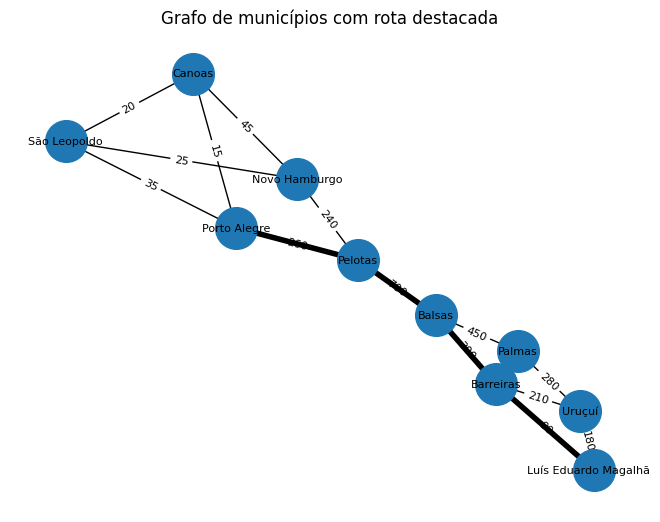

In [13]:
visualizar_grafo(
    grafo,
    municipios,
    resultado_dijkstra["caminho"]
)